In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 第一题

In [4]:
rating = pd.read_excel('./data/rating.xlsx')
rating

,UserID,MovieID,Rating,padate,month
0,1,2355,5,2001-01-06 23:38:11,1
1,1,595,5,2001-01-06 23:37:48,1
2,1,2687,3,2001-01-06 23:37:48,1
3,1,527,5,2001-01-06 23:36:35,1
4,1,48,5,2001-01-06 23:39:11,1
...,...,...,...,...,...
68053,6040,1333,4,2001-08-10 14:35:40,8
68054,6040,3362,4,2001-08-10 14:29:56,8
68055,6040,161,3,2001-08-10 14:41:26,8
68056,6040,2725,4,2001-08-10 14:36:20,8


任务：计算各月各评分的总人数

各月各评分的总人数：
Rating    1     2     3     4     5
month                              
1       825  2037  5131  6547  3464
2       423   923  2153  3018  1619
3       275   698  1743  2272  1095
4       326   629  1442  1830   944
5       259   593  1449  1889   749
6       261   635  1438  1782   865
7       268   573  1343  1782   799
8       304   557  1199  1540   854
9       131   345   899  1132   570
10      133   309   616   782   352
11      118   306   780   930   626
12      216   381   957  1335   607


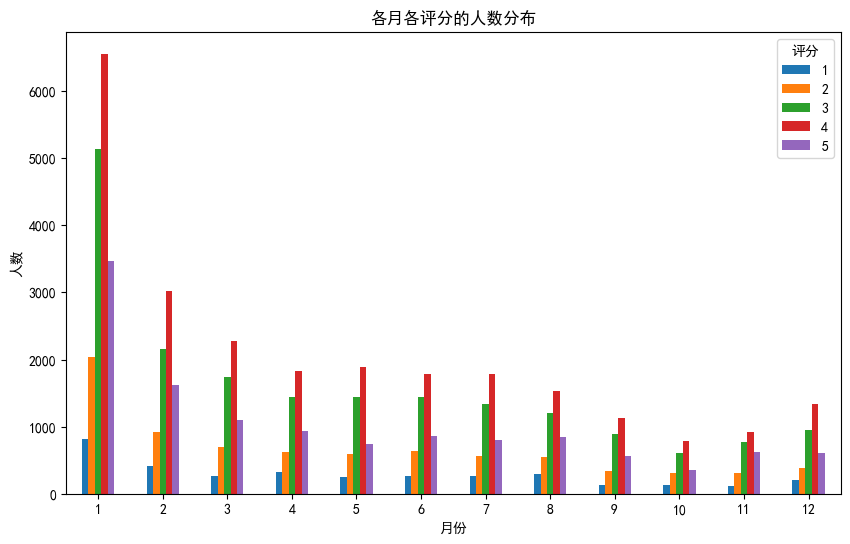

In [ ]:
month_rating_count = rating.pivot_table(
    index='month', 
    columns='Rating', 
    values='UserID', 
    aggfunc='count',
    fill_value=0  # 缺失值用0填充
)

# 3. 输出结果（和题目表格一致）
print("各月各评分的总人数：")
print(month_rating_count)

# 4. 数据可视化（可选，更直观展示）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文乱码 显示字体为黑体

plt.figure(figsize=(10, 6))# 创建一个10英寸宽，6英寸高的的图表
month_rating_count.plot(kind='bar', stacked=False, ax=plt.gca())# 绘制柱状图
plt.title('各月各评分的人数分布')
plt.xlabel('月份')
plt.ylabel('人数')
plt.legend(title='评分')
plt.xticks(rotation=0) # 旋转x轴标签，防止重叠

plt.show()

# 第二题

In [ ]:
df1 = pd.read_csv("./data/000001_daily.csv")
df2 = pd.read_csv("./data/000001_5min.csv")
df1.head()

,日期,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2017/1/3,8.27,8.32,8.34,8.25,459840,420595184,1.09,0.73,0.06,0.31
1,2017/1/4,8.31,8.32,8.34,8.30,449330,411503440,0.48,0.00,0.00,0.31
2,2017/1/5,8.33,8.33,8.34,8.31,344373,315769696,0.36,0.12,0.01,0.24
3,2017/1/6,8.33,8.29,8.33,8.27,358154,327176432,0.72,-0.48,-0.04,0.24
4,2017/1/9,8.29,8.31,8.33,8.27,361082,329994608,0.72,0.24,0.02,0.21


In [ ]:
df2.head()

,时间,开盘,收盘,最高,最低,涨跌幅,涨跌额,成交量,成交额,振幅,换手率
0,2021/8/3 9:35,17.99,17.78,18.02,17.75,-1.28,-0.23,52807,94339287,1.50,0.03
1,2021/8/3 9:40,17.77,17.76,17.83,17.66,-0.11,-0.02,41508,73683531,0.96,0.02
2,2021/8/3 9:45,17.77,17.77,17.83,17.73,0.06,0.01,18521,32915794,0.56,0.01
3,2021/8/3 9:50,17.77,17.72,17.78,17.70,-0.28,-0.05,24424,43323693,0.45,0.01
4,2021/8/3 9:55,17.71,17.77,17.78,17.70,0.28,0.05,23197,41110937,0.45,0.01


## 将两个数据集中与时间相关的列转换为时间格式（datetime64[ns]）

In [ ]:
df1['日期'] = pd.to_datetime(df1['日期'])
df2['时间'] = pd.to_datetime(df2['时间'])
# df1['日期'] = df1['日期'].astype('datetime64[ns]')

## 按周对 df1 进行降采样，保留每周的均值

In [9]:
# 将时间列设为索引
df1_weekly = df1.set_index('日期')
# W代表按周重采样，默认周日为一周最后一天，也可以用W-MON指定周一为起始
df1_week_mean = df1_weekly.resample(rule='W').mean()
# 查看结果
df1_week_mean.head()

,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
日期,,,,,,,,,,
2017-01-08,8.3100,8.315,8.3375,8.2825,402924.25,368761188.0,0.6625,0.0925,0.0075,0.275
2017-01-15,8.2980,8.310,8.3320,8.2860,353575.00,323518850.2,0.5520,0.0720,0.0060,0.208
2017-01-22,8.3060,8.332,8.3560,8.2840,526805.80,482388579.2,0.8640,0.1440,0.0120,0.310
2017-01-29,8.4075,8.430,8.4500,8.3875,403914.50,374156844.0,0.7450,0.3275,0.0275,0.240
2017-02-05,8.5000,8.420,8.5200,8.3900,315472.00,292617936.0,1.5300,-0.8200,-0.0700,0.190


## 按日对 df2 进行重采样，保留每天的均值

In [10]:
# 将时间列设为索引
df2_daily = df2.set_index('时间')
# D代表按自然日重采样
df2_day_mean = df2_daily.resample(rule='D').mean()
# 查看结果
df2_day_mean.head()

,开盘,收盘,最高,最低,涨跌幅,涨跌额,成交量,成交额,振幅,换手率
时间,,,,,,,,,,
2021-08-03,17.953958,17.950833,17.990417,17.918958,-0.013958,-0.002500,18686.479167,3.352964e+07,0.397708,0.010625
2021-08-04,17.821458,17.813125,17.850625,17.781042,-0.009375,-0.001667,15200.395833,2.708676e+07,0.389375,0.007708
2021-08-05,17.793750,17.792500,17.829375,17.751667,-0.014792,-0.002708,12949.500000,2.301881e+07,0.437083,0.006667
2021-08-06,17.735625,17.743125,17.773542,17.708750,0.021250,0.003750,11821.979167,2.095564e+07,0.366042,0.006458
2021-08-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 第三题

In [6]:
import matplotlib.pyplot as plt                 
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
data = load_iris()
print(data)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [12]:
iris = load_iris()
X = iris.data  # 原始4维特征数据
y = iris.target  # 标签（花的种类）

# 2. 初始化PCA，设置降维到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # 执行降维

# 3. 打印维度验证
print("原始数据维度：", X.shape)
print("降维后数据维度：", X_pca.shape)



原始数据维度： (150, 4)
降维后数据维度： (150, 2)
